# American Options Pricing — Longstaff-Schwartz Algorithm

This notebook visualises the outputs of a **C++ implementation of the LSM algorithm** for pricing American put options. The data is generated by compiling and running the C++ binary (`lsm_main`), which writes simulation data to `csv_output/`. This notebook reads those CSVs and reproduces the analyses

### Model

The underlying asset follows **Geometric Brownian Motion**:

$$dX_t = r X_t \, dt + \sigma X_t \, dW_t, \qquad X_0 = x_0$$


## Imports & Configuration


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [2]:

csv_dir  = "csv_output"
Plots_dir = "plots"
os.makedirs(Plots_dir, exist_ok=True)

K = 1.1
r = 0.02
SIGMA = 0.15
T = 6.0
X0 = 1.0

### Matplotlib Config

In [ ]:
GOLD = "#F5C518"
BLUE = "#3A7DC9"
GREEN = "#2ECC71"
RED = "#E74C3C"
PURPLE = "#8E44AD"
GREY = "#4A4A4A"
DARK_GREY = "#1F1F1F"
ORANGE = "#E67E22"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color":"#E0E0E0",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
    "figure.dpi": 120,
})

### Load Data


`paths.csv` - Wide matrix: `t, path_0 ... path_{N-1}` 

`paths_itm.csv` - Long: `path_id, t, price, itm` 

`payoff.csv` - Long: `path_id, t, price, payoff` 

`cashflows.csv` - Sparse: non-zero only at exercise events 

`exercise_times.csv` - Per path: when & where the put was exercised 

`regression_scatter.csv` - Scatter data at $t_{n-1}$ 

`regression_grid.csv` - Fitted continuation curve on a fine grid 

`price_summary.csv` - American, European, premium, std error 


In [4]:
def load_paths_wide():
    """Returns (times array shape (T+1,), paths matrix shape (N, T+1))."""
    df = pd.read_csv(f"{csv_dir}/paths.csv")
    times = df["t"].values
    path_cols = [c for c in df.columns if c.startswith("path_")]
    return times, df[path_cols].values.T

def csv(name):
    return pd.read_csv(f"{csv_dir}/{name}")

times, paths = load_paths_wide()
df_itm = csv("paths_itm.csv")
df_payoff = csv("payoff.csv")
df_cf = csv("cashflows.csv")
df_exercise = csv("exercise_times.csv")
df_scatter = csv("regression_scatter.csv")
df_grid = csv("regression_grid.csv")
df_summary = csv("price_summary.csv").set_index("label")["value"]

N = paths.shape[0]
print(f"Paths loaded: {N} paths x {paths.shape[1]} time steps")
print(df_summary.to_string())


Paths loaded: 50 paths x 121 time steps
label
american                    0.171857
european                    0.096228
early_exercise_premium      0.075629
std_error                   0.020181
num_paths                  50.000000
num_exercise_dates        120.000000


## Simulated GBM Paths

We simulate $N$ sample paths of the GBM using the exact discretisation:

$$X_{t+dt} = X_t \exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)dt + \sigma\sqrt{dt}\,Z\right], \quad Z \sim \mathcal{N}(0,1)$$

The theoretical conditional mean is $\mathbb{E}[X_t] = x_0 e^{rt}$.


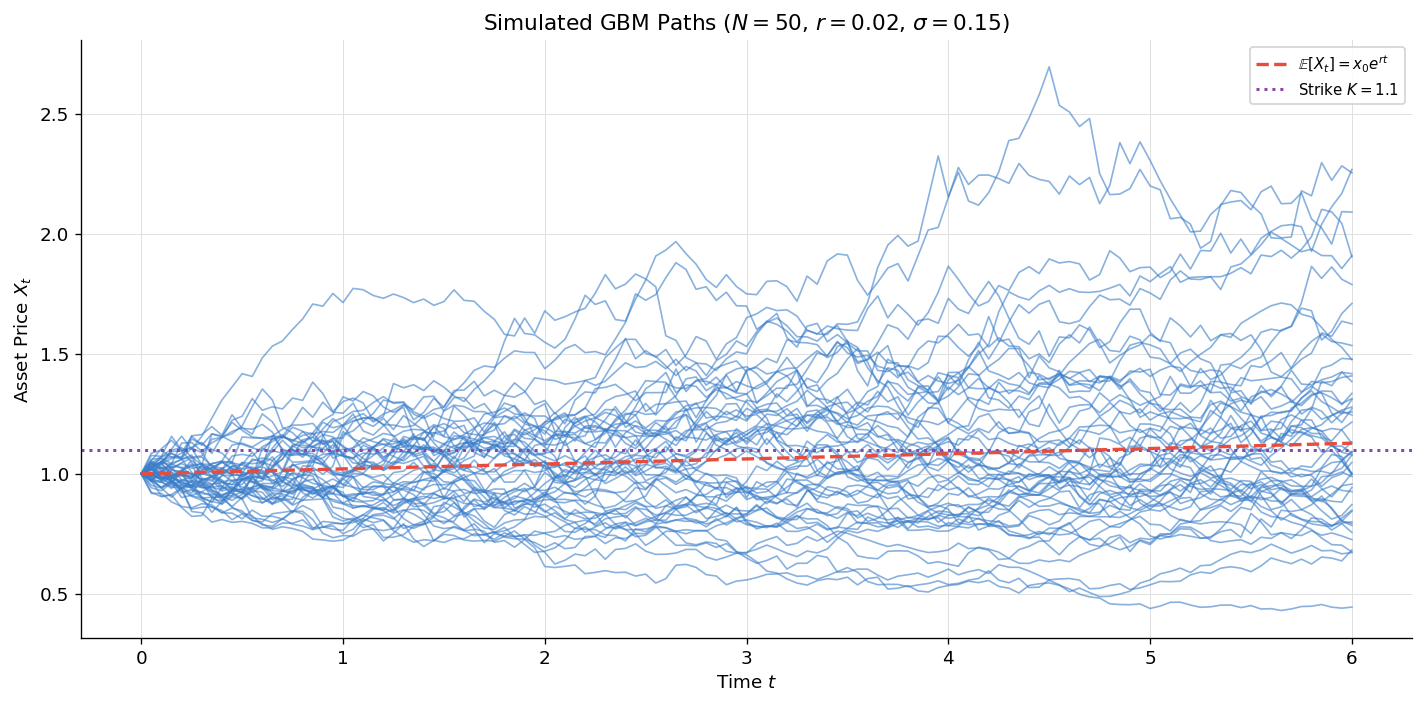

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for p in paths:
    ax.plot(times, p, color=BLUE, alpha=0.6, lw=1.0)

mean_line = X0 * np.exp(r * times)
ax.plot(times, mean_line, color=RED, lw=2.0, ls="--",
        label=r"$\mathbb{E}[X_t] = x_0 e^{rt}$", zorder=5)
ax.axhline(K, color=PURPLE, ls=":", lw=1.8, label=f"Strike $K = {K}$")

ax.set_xlabel("Time $t$")
ax.set_ylabel("Asset Price $X_t$")
ax.set_title(f"Simulated GBM Paths ($N={N}$, $r={r}$, $\\sigma={SIGMA}$)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig1_simulated_paths.png", bbox_inches="tight")
plt.show()


## Paths Coloured ITM / OTM

At each grid point $t_i$ we classify:
- **Gold** — in the money ($X_{t_i} < K$): the put has positive intrinsic value, early exercise *may* be optimal
- **Blue** — out of the money ($X_{t_i} \geq K$): the put is worthless to exercise now


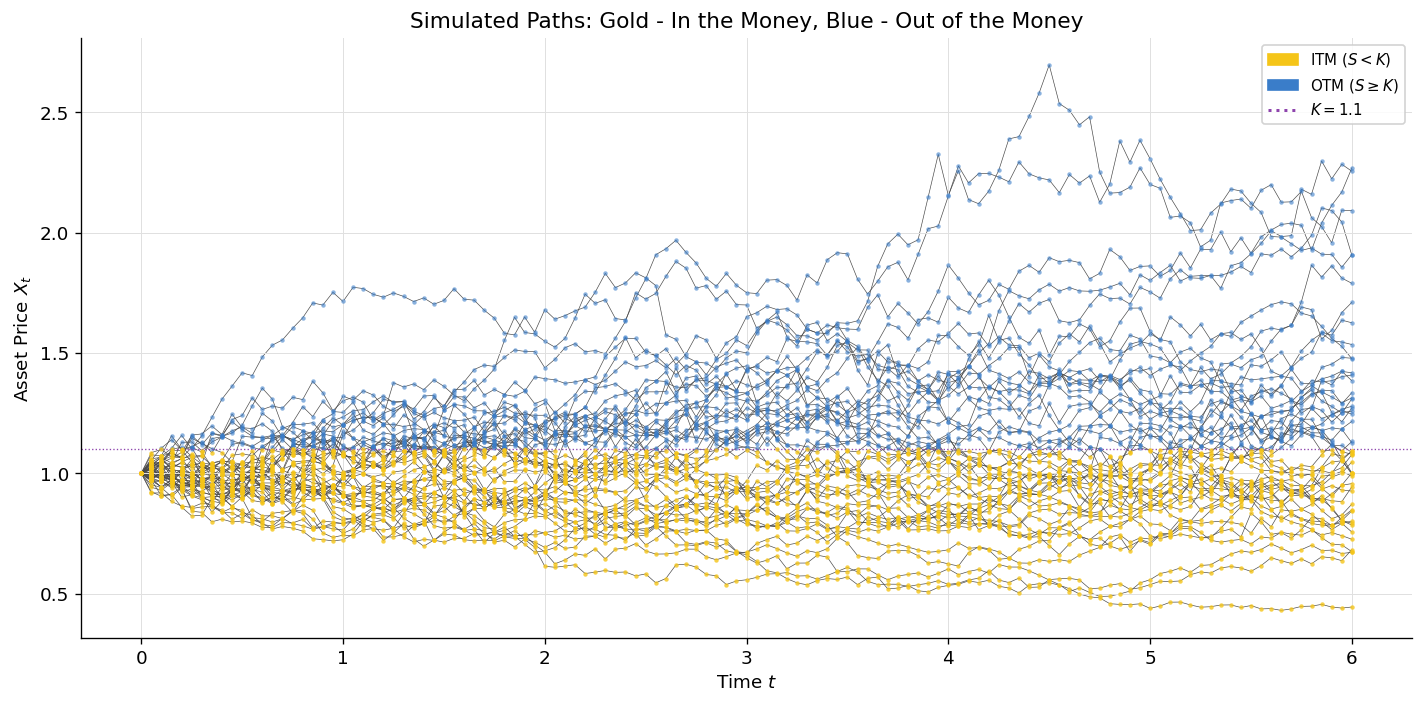

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for pid in df_itm["path_id"].unique():
    sub = df_itm[df_itm["path_id"] == pid].sort_values("t")
    t_vals = sub["t"].values
    prices = sub["price"].values
    itm = sub["itm"].values == 1

    ax.plot(t_vals, prices, color=GREY, lw=0.4, zorder=1)
    ax.scatter(t_vals[ itm], prices[ itm], c=GOLD, s=7, zorder=3, alpha=0.8, linewidths=0)
    ax.scatter(t_vals[~itm], prices[~itm], c=BLUE, s=7, zorder=2, alpha=0.6, linewidths=0)

ax.axhline(K, color=PURPLE, ls=":", lw=0.8)
ax.legend(handles=[
    mpatches.Patch(color=GOLD, label="ITM ($S < K$)"),
    mpatches.Patch(color=BLUE, label="OTM ($S \\geq K$)"),
    mlines.Line2D([], [], color=PURPLE, ls=":", lw=1.8, label=f"$K={K}$"),
])
ax.set_xlabel("Time $t$")
ax.set_ylabel("Asset Price $X_t$")
ax.set_title("Simulated Paths: Gold - In the Money, Blue - Out of the Money")
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig2_paths_itm.png", bbox_inches="tight")
plt.show()


## Put Payoff Surface

The instantaneous exercise value (put payoff) at each grid point is:

$$Y(t_i) = (K - X_{t_i})^+ = \max(K - X_{t_i},\, 0)$$

When $X_t \geq K$ the payoff is zero; below the strike it increases linearly.


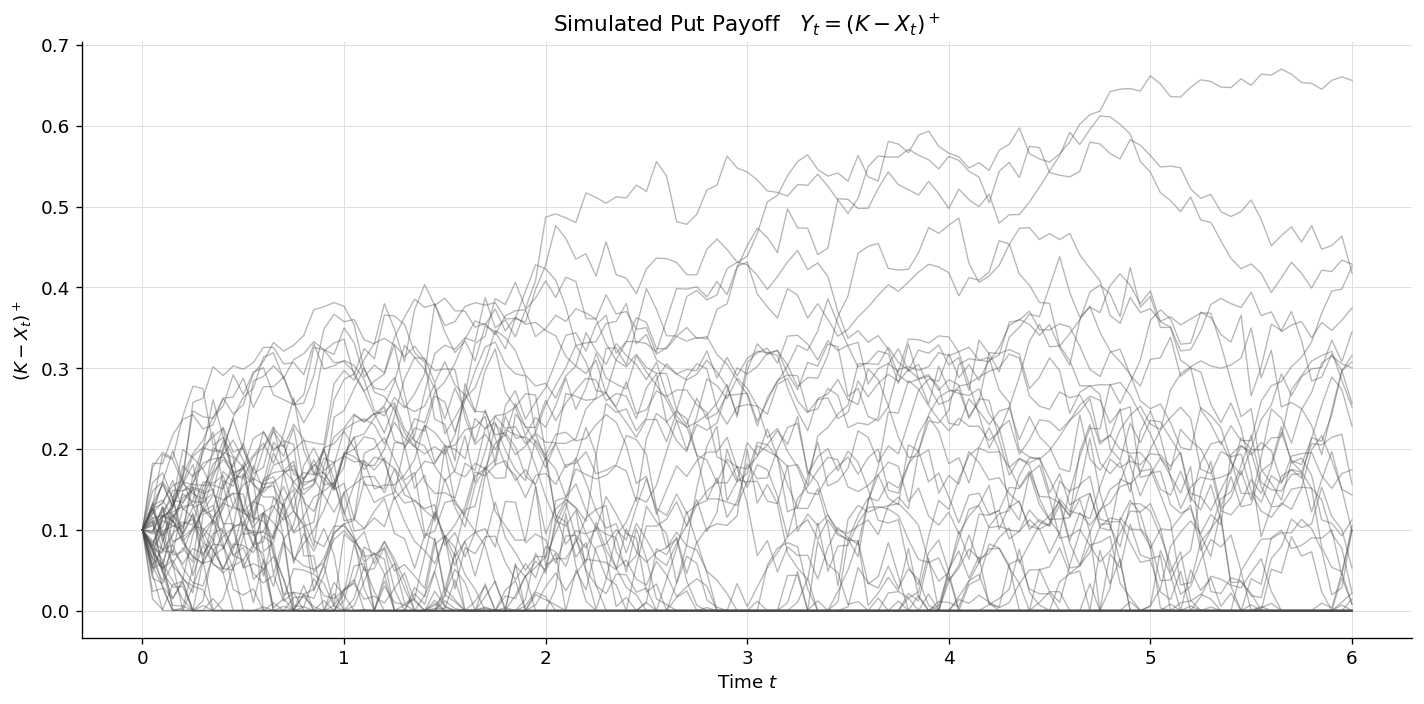

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for pid in df_payoff["path_id"].unique():
    sub = df_payoff[df_payoff["path_id"] == pid].sort_values("t")
    ax.plot(sub["t"].values, sub["payoff"].values, color=GREY, lw=0.8, alpha=0.4)

ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$(K - X_t)^+$")
ax.set_title(r"Simulated Put Payoff   $Y_t = (K - X_t)^+$")
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig3_payoff_surface.png", bbox_inches="tight")
plt.show()


## Regression Fit at $t_{n-1}$ 

The core of LSM is approximating the **continuation value** $C(t_i)$ using OLS regression.

At each step $t_i$ (working backwards), for the ITM paths only, we regress
the **discounted future cashflow** $e^{-r\,dt} \cdot U(t_{i+1})$ onto the current stock price
using a Laguerre polynomial basis:

$$C(t_i) \approx \sum_{j=0}^{3} \hat{\alpha}_j \, L_j\bigl(X(t_i)\bigr)$$

The plots below show this at $t_{n-1}$ (the second-to-last step).

- **Left**: discounted cashflow scatter + fitted Laguerre curve
- **Right**: exercise value vs fitted continuation, with shaded decision regions


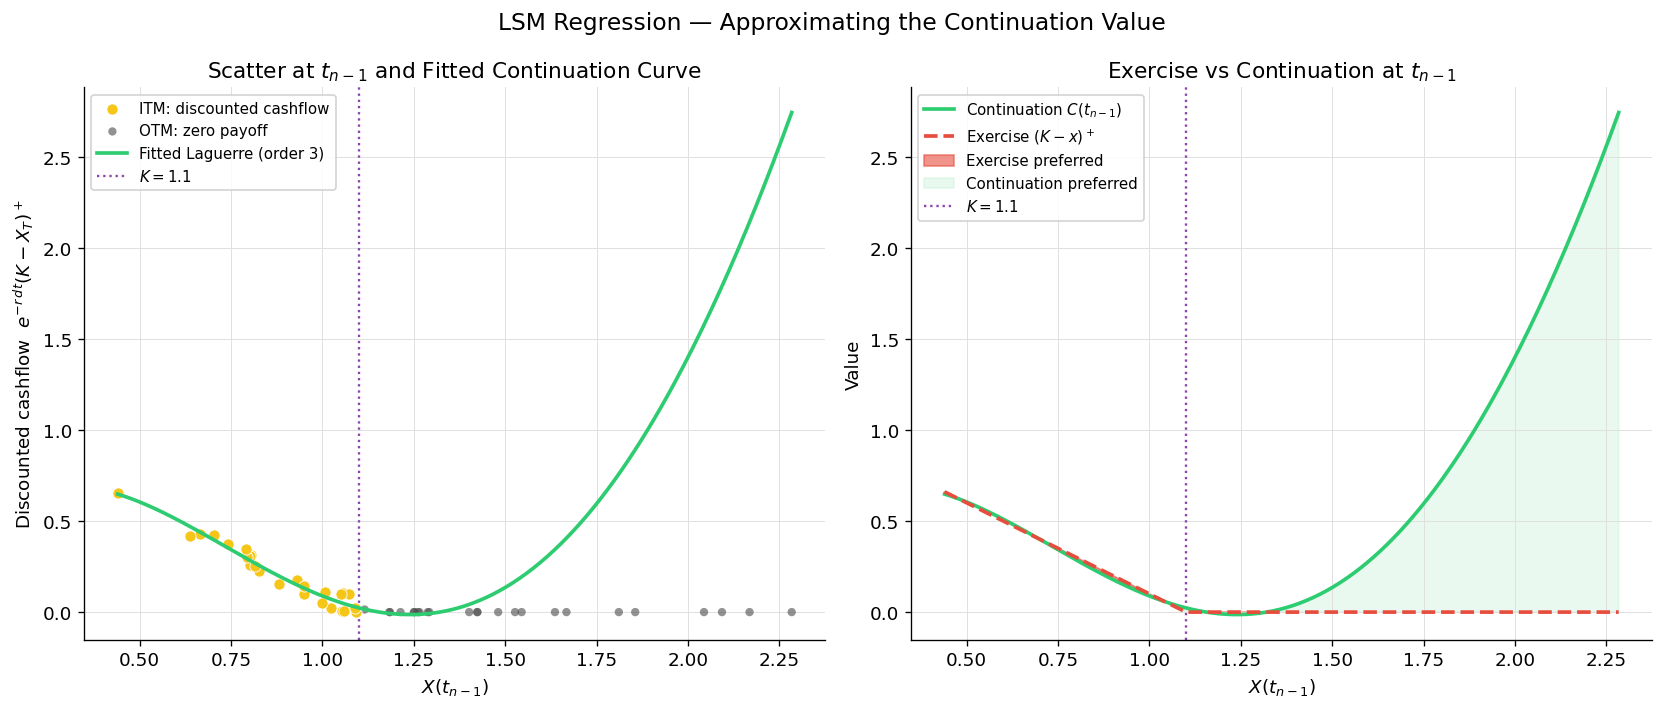

In [8]:
itm_mask = df_scatter["itm"] == 1
otm_mask = ~itm_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter and fitted curve 
ax = axes[0]
ax.scatter(df_scatter.loc[itm_mask, "x"], df_scatter.loc[itm_mask, "discounted_cf"],
           c=GOLD, s=45, zorder=4, edgecolors="white", linewidths=0.5,
           label="ITM: discounted cashflow")
ax.scatter(df_scatter.loc[otm_mask, "x"], df_scatter.loc[otm_mask, "discounted_cf"],
           c=GREY, s=25, zorder=3, alpha=0.6, edgecolors="none",
           label="OTM: zero payoff")
ax.plot(df_grid["x"], df_grid["continuation_value"],
        color=GREEN, lw=2.2, zorder=5, label="Fitted Laguerre (order 3)")
ax.axvline(K, color=PURPLE, ls=":", lw=1.4, label=f"$K = {K}$")
ax.set_xlabel(r"$X(t_{n-1})$")
ax.set_ylabel(r"Discounted cashflow  $e^{-r\,dt}(K-X_T)^+$")
ax.set_title(r"Scatter at $t_{n-1}$ and Fitted Continuation Curve")
ax.legend()

# Right: exercise vs continuation
ax2 = axes[1]
x_g  = df_grid["x"].values
cont = df_grid["continuation_value"].values
exv  = df_grid["exercise_value"].values
ex_better = exv > cont

ax2.plot(x_g, cont, color=GREEN, lw=2.2, label="Continuation $C(t_{n-1})$", zorder=4)
ax2.plot(x_g, exv,  color=RED,   lw=2.2, ls="--",
         label=r"Exercise $(K-x)^+$", zorder=4)
ax2.fill_between(x_g, exv, cont, where=ex_better,
                 color=RED,   alpha=0.6, label="Exercise preferred")
ax2.fill_between(x_g, exv, cont, where=~ex_better,
                 color=GREEN, alpha=0.10, label="Continuation preferred")
ax2.axvline(K, color=PURPLE, ls=":", lw=1.4, label=f"$K = {K}$")
ax2.set_xlabel(r"$X(t_{n-1})$")
ax2.set_ylabel("Value")
ax2.set_title(r"Exercise vs Continuation at $t_{n-1}$")
ax2.legend()

fig.suptitle("LSM Regression — Approximating the Continuation Value", fontsize=14)
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig4_regression_fit.png", bbox_inches="tight")
plt.show()


## Exercise vs Continuation Decision

After running the full backward induction across all time steps, we can map out
every ITM grid point and whether the algorithm decided to **exercise** or **continue**.

- **Red** — exercise was optimal: $Y(t) > C(t)$
- **Green** — continuation was optimal: $Y(t) \leq C(t)$

Only ITM paths are shown (OTM paths trivially continue).


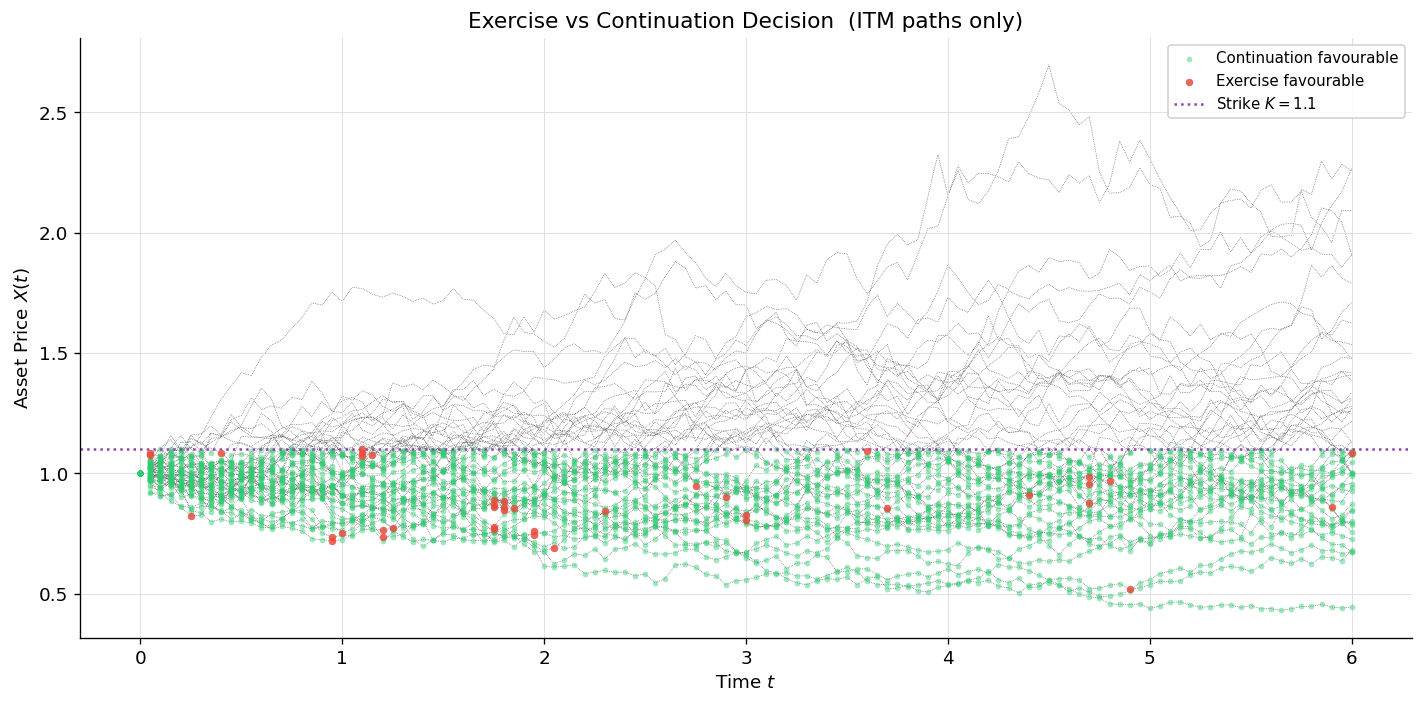

In [9]:
# Build a set of (path_id, t) pairs where a cashflow was paid ( exercise event)
df_cf["t_r"] = df_cf["t"].round(6)
exercise_set = set(zip(df_cf["path_id"], df_cf["t_r"]))

# Label every ITM grid point
df_itm_copy = df_itm[df_itm["itm"] == 1].copy()
df_itm_copy["t_r"] = df_itm_copy["t"].round(6)
df_itm_copy["exercised"] = df_itm_copy.apply(
    lambda row: (row["path_id"], row["t_r"]) in exercise_set, axis=1
)

cont_pts = df_itm_copy[~df_itm_copy["exercised"]]
ex_pts = df_itm_copy[ df_itm_copy["exercised"]]

fig, ax = plt.subplots(figsize=(12, 6))

for p in paths:
    ax.plot(times[1:], p[1:], ":", color=GREY, lw=0.4, zorder=1)

ax.scatter(cont_pts["t"], cont_pts["price"],
           c=GREEN, s=12, alpha=0.45, zorder=2, linewidths=0,
           label="Continuation favourable")
ax.scatter(ex_pts["t"], ex_pts["price"],
           c=RED, s=20, alpha=0.85, zorder=3, linewidths=0,
           label="Exercise favourable")

ax.axhline(K, color=PURPLE, ls=":", lw=1.5, label=f"Strike $K = {K}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Asset Price $X(t)$")
ax.set_title("Exercise vs Continuation Decision  (ITM paths only)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig5_exercise_vs_continuation.png", bbox_inches="tight")
plt.show()


## Decision Map Across All Paths 

Each simulated path is drawn with colour encoding the decision:

| Colour | Meaning |
|---|---|
| Green solid | Path up to (and including) the exercise point |
| Grey dashed | Path after early exercise (option already exercised) |
| Blue solid | Path held to maturity without early exercise |
| Red dot | Exercise event |


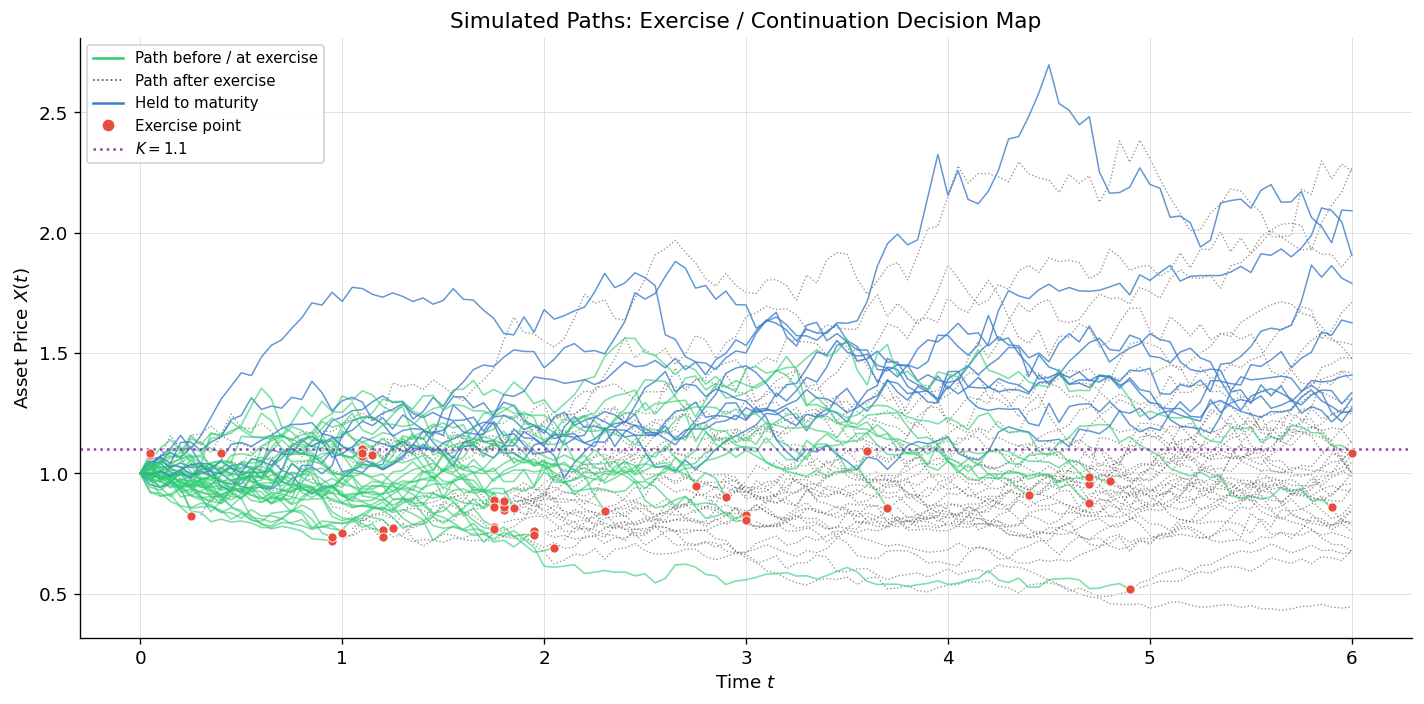

In [10]:
# Map path_id to earliest exercise time
ex_map = df_cf.groupby("path_id")["t"].min().to_dict()

fig, ax = plt.subplots(figsize=(12, 6))

for i, p in enumerate(paths):
    ex_t = ex_map.get(i, None)
    if ex_t is not None:
        mask = times <= ex_t + 1e-9
        ax.plot(times[ mask], p[ mask], color=GREEN, lw=1.0, alpha=0.6, zorder=2)
        ax.plot(times[~mask], p[~mask], ":", color=GREY, lw=0.8, alpha=0.6, zorder=1)
        idx = np.argmin(np.abs(times - ex_t))
        ax.scatter(times[idx], p[idx], c=RED, s=30, zorder=4,
                   linewidths=0.5, edgecolors="white")
    else:
        ax.plot(times, p, color=BLUE, lw=0.9, alpha=0.8, zorder=2)

ax.axhline(K, color=PURPLE, ls=":", lw=1.5)
ax.legend(handles=[
    mlines.Line2D([], [], color=GREEN, lw=1.5, label="Path before / at exercise"),
    mlines.Line2D([], [], color=GREY, lw=1.0, ls=":", label="Path after exercise"),
    mlines.Line2D([], [], color=BLUE, lw=1.5, label="Held to maturity"),
    mlines.Line2D([], [], color=RED,marker="o", ls="none", markersize=6, label="Exercise point"),
    mlines.Line2D([], [], color=PURPLE, lw=1.5, ls=":", label=f"$K={K}$"),
])
ax.set_xlabel("Time $t$")
ax.set_ylabel("Asset Price $X(t)$")
ax.set_title("Simulated Paths: Exercise / Continuation Decision Map")
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig6_decision_map.png", bbox_inches="tight")
plt.show()


## First Early Exercise Instances

In LSM, the option is exercised at the **first** time step where exercise beats continuation.
Once the option is exercised, subsequent path values are irrelevant — shown as dashed grey.

The **red dot** marks the exact exercise point for each path.


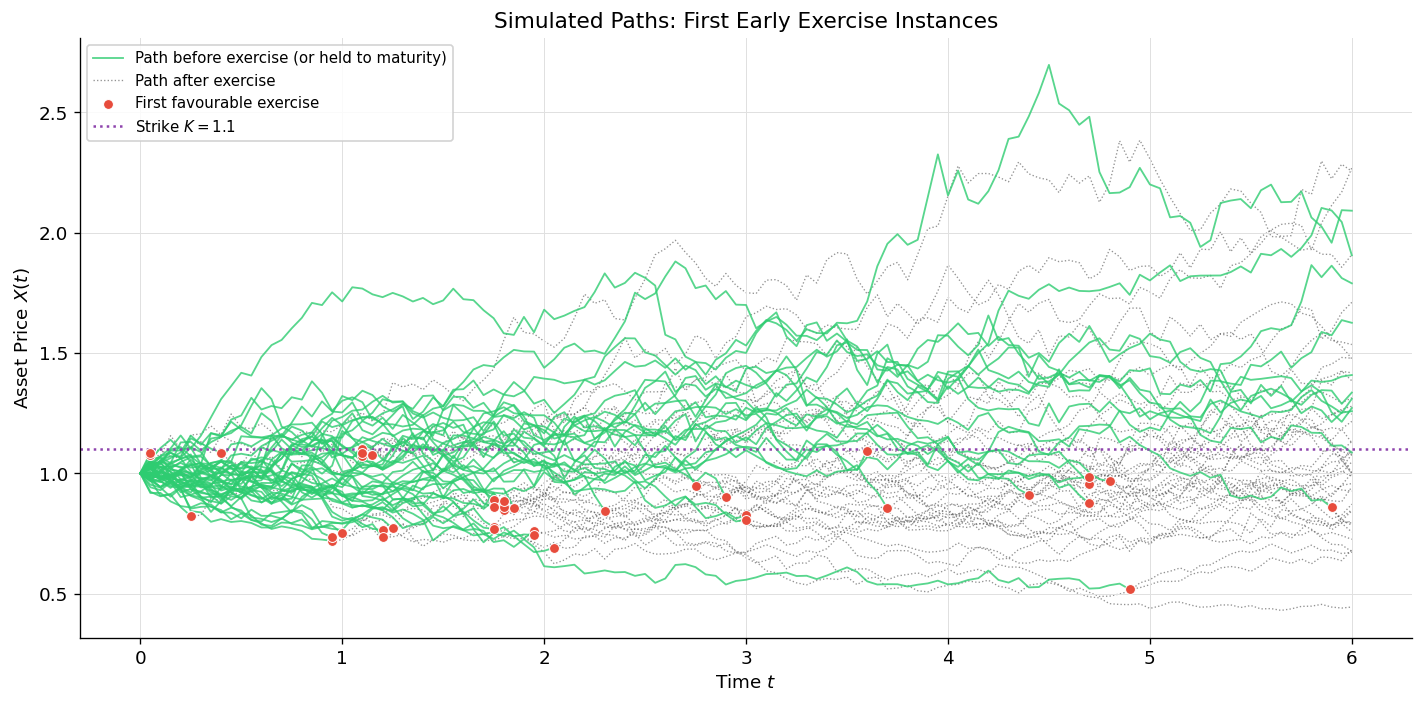

In [11]:
ex_sorted = df_exercise.sort_values("path_id")
ex_t_arr  = ex_sorted["exercise_t"].values
held_arr  = ex_sorted["held_to_maturity"].values.astype(bool)

fig, ax = plt.subplots(figsize=(12, 6))
h_before = h_after = h_expt = None

for i, p in enumerate(paths):
    ex_t = ex_t_arr[i]
    held = held_arr[i]
    stop = np.argmin(np.abs(times - ex_t))

    l1, = ax.plot(times[:stop + 1], p[:stop + 1],
                  color=GREEN, lw=1.1, alpha=0.8, zorder=2)
    if h_before is None: h_before = l1

    if not held:
        l2, = ax.plot(times[stop:], p[stop:], ":", color=GREY, lw=0.8, alpha=0.6, zorder=1)
        if h_after is None: h_after = l2
        sc = ax.scatter(times[stop], p[stop], c=RED, s=35, zorder=5,
                        linewidths=0.6, edgecolors="white")
        if h_expt is None: h_expt = sc

ax.axhline(K, color=PURPLE, ls=":", lw=1.5)

handles = [h_before]
labels  = ["Path before exercise (or held to maturity)"]
if h_after: handles.append(h_after); labels.append("Path after exercise")
if h_expt:  handles.append(h_expt);  labels.append("First favourable exercise")
handles.append(mlines.Line2D([], [], color=PURPLE, ls=":", lw=1.5))
labels.append(f"Strike $K = {K}$")

ax.legend(handles, labels)
ax.set_xlabel("Time $t$")
ax.set_ylabel("Asset Price $X(t)$")
ax.set_title("Simulated Paths: First Early Exercise Instances")
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig7_first_exercise.png", bbox_inches="tight")
plt.show()


## American vs European Price Summary

The American option value must satisfy:

$$V^{\text{American}} \geq V^{\text{European}}$$

because early exercise is an additional right that can only add value. The difference:

$$\text{Early Exercise Premium} = V^{\text{American}} - V^{\text{European}} \geq 0$$

The European price here is the plain Monte Carlo estimate $e^{-rT}\,\mathbb{E}[(K-X_T)^+]$
computed from the same simulated paths, serving as a lower-bound benchmark.


In [12]:
american = float(df_summary["american"])
european = float(df_summary["european"])
premium  = float(df_summary["early_exercise_premium"])
std_err  = float(df_summary["std_error"])
n_paths  = int(float(df_summary["num_paths"]))
n_dates  = int(float(df_summary["num_exercise_dates"]))

print(f"American price : {american:.6f}")
print(f"European price (MC) : {european:.6f}")
print(f"Early exercise premium : {premium:.6f}")
print(f"Monte Carlo std error : {std_err:.6f}")


American price : 0.171857
European price (MC) : 0.096228
Early exercise premium : 0.075629
Monte Carlo std error : 0.020181


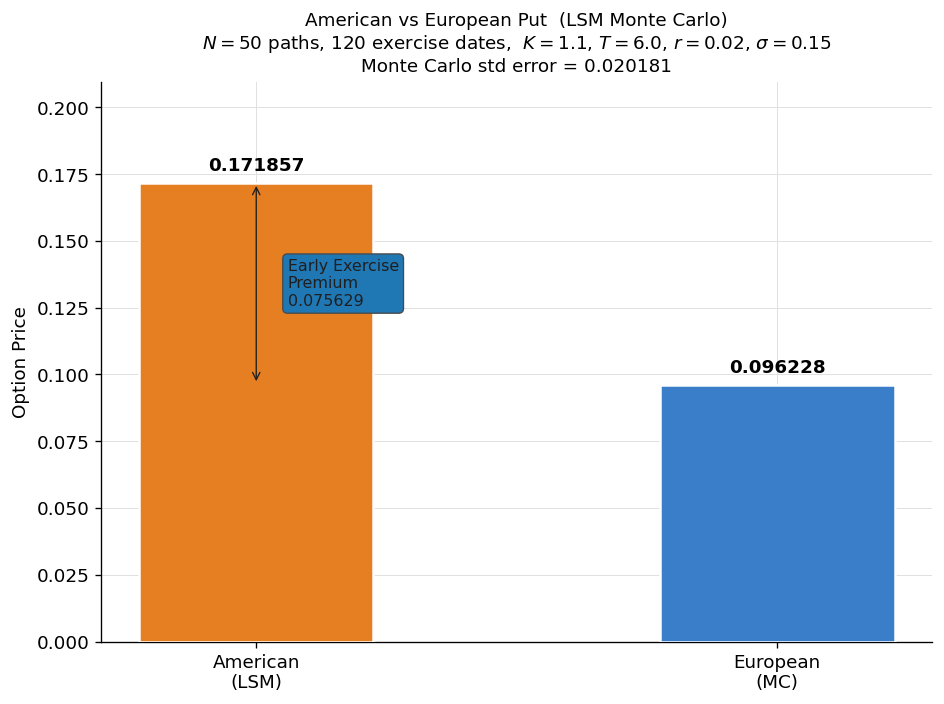

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    ["American\n(LSM)", "European\n(MC)"],
    [american, european],
    color=[ORANGE, BLUE], width=0.45,
    edgecolor="white", linewidth=1.5, zorder=3
)

for bar, v in zip(bars, [american, european]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
            f"{v:.6f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

x_am  = bars[0].get_x() + bars[0].get_width() / 2
y_mid = (american + european) / 2
ax.annotate("", xy=(x_am, european), xytext=(x_am, american),
            arrowprops=dict(arrowstyle="<->", color=DARK_GREY, lw=0.8))
ax.text(x_am + 0.06, y_mid,
        f"Early Exercise\nPremium\n{premium:.6f}",
        ha="left", va="center", fontsize=9.5, color=DARK_GREY,
        bbox=dict(boxstyle="round,pad=0.3", ec=GREY, lw=0.8))

ax.set_ylabel("Option Price")
ax.set_ylim(0, max(american, european) * 1.22)
ax.set_title(
    f"American vs European Put  (LSM Monte Carlo)\n"
    f"$N={n_paths}$ paths, {n_dates} exercise dates,  "
    f"$K={K}$, $T={T}$, $r={r}$, $\\sigma={SIGMA}$\n"
    f"Monte Carlo std error = {std_err:.6f}",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"{Plots_dir}/fig8_price_summary.png", bbox_inches="tight")
plt.show()


----
The styling and formatting of the plots are inspired by the LSM pricer implementation by [LSM Pricer, Dialid Santiago](https://quantgirluk.github.io/Understanding-Quantitative-Finance/AOS.html)